Breakdown:

potentials.py

solver.py (The main function)

Then, a fourth file, main_app.py, will bring everything together, handle the MediaPipe input, and plot the results.

 # Just an Infinite Potential Square Well


 Ultimately I want:



 - A clean, modular solver that works for **custom 1D potentials**.

 - Later: **GPU acceleration**, nicer **UI**, maybe interactive widgets.



 Technical / numerical TODO:



 - Rigorous boundary-condition (BC) enforcement(Dirichlet for infinite well)

 - Orthonormality diagnostic plots (implemented, but can be refined)

 - Convergence analysis

   - e.g. compare $N = 500$ vs $N = 2000$ to see how the discrete operator $\mathbf{D2}$ behaves

 - Analytic solution benchmarking

   - For the infinite square well: compare $E_n$ to

     $$

     E_n = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

     $$

 - Documentation + modular design


---

## 0. Quantum picture: what am I actually solving?

Before getting lost in matrices and `numpy`, I want to be clear what the **physics problem** is.

In the postulate language of quantum mechanics:

- A **state** of the particle is described by a wavefunction $$\Psi(x)$$ 
  (or more abstractly, a vector $$|\Psi\rangle$$ in a Hilbert space).

- **Observables** (like energy) are represented by **Hermitian operators**.
  For a particle in 1D with potential $$V(x)$$, the Hamiltonian operator is

  $$
  \hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x).
  $$

- The **energy eigenstates** are solutions of

  $$
  \hat{H}\,\psi_n(x) = E_n \,\psi_n(x),
  $$

  with boundary conditions and normalization:

  $$
  \int |\psi_n(x)|^2 dx = 1.
  $$

Physically:

- Each $$\psi_n(x)$$ is a **stationary state**: if the system is prepared in $$\psi_n$$, the probability density
  $$|\psi_n(x,t)|^2$$ is independent of time (it only picks up a phase $$e^{-iE_n t/\hbar}$$).

- The energies $$E_n$$ are the possible outcomes of a precise **energy measurement**.

- A general state can be expanded as

  $$
  \Psi(x,0) = \sum_n c_n \psi_n(x),
  $$

  and then evolves as

  $$
  \Psi(x,t) = \sum_n c_n \psi_n(x)\,e^{-iE_n t/\hbar}.
  $$

So my numerical solver is really a machine that takes a **chosen potential** $$V(x)$$ and returns:

- The discrete spectrum $$\{E_n\}$$ (energy levels for that potential).
- The corresponding eigenfunctions $$\psi_n(x)$$ (stationary states).

Once I have those, I can in principle build **any** time-dependent solution by choosing coefficients $$c_n$$.


---


# %% [markdown]
### 2.2.1 Infinite wall as a limit of a finite barrier

Another way to see $$\Psi(0) = \Psi(a) = 0$$:

- Start with a **finite** but huge barrier outside $$[0,a]$$:
  
  - $$V(x) = 0$$ for $$0 < x < a$$,
  - $$V(x) = V_0$$ (large but finite) for $$x \le 0$$ and $$x \ge a$$.

- For a bound state with energy $$E < V_0$$, the solution in the barrier region decays exponentially
  (evanescent tail). As $$V_0 \to \infty$$, the decay length goes to zero, and the wavefunction is
  squeezed to exactly zero at the wall.

So the infinite square well is an **idealized limit** where those evanescent tails are completely killed.
In that limit, the physically acceptable states are exactly those that vanish at the boundaries.

### 2.2.2 Probability current and “no leakage”

The boundary conditions are also tied to **probability conservation**.

The probability current in 1D is

$$
j(x) = \frac{\hbar}{m}\,\text{Im}\big(\Psi^*(x)\,\partial_x \Psi(x)\big).
$$

For a particle trapped in the well, there should be **no net probability flow out** of the region.
Taking $$\Psi(0) = \Psi(a) = 0$$ ensures that $$j(0) = j(a) = 0$$, so there is no leakage of probability
through the walls. This is part of making $$\hat{H}$$ self-adjoint with these boundary conditions.

---

# %% [markdown]
### 2.3.1 Physical interpretation: standing waves, nodes, and quantization

The infinite well is a quantum version of a **string fixed at both ends**:

- The boundary conditions $$\Psi(0) = \Psi(a) = 0$$ only allow certain “standing wave” shapes.
- Those shapes are exactly

  $$
  \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n\pi x}{a}\right),
  $$

  with integer $$n = 1,2,3,\dots$$

Each $$n$$ has:

- $$n-1$$ internal **nodes** (points where $$\Psi_n(x) = 0$$ inside the well).
- Increasing **curvature** of the wavefunction, which corresponds to higher kinetic energy.

This is why the energies scale like

$$
E_n \propto n^2.
$$

The key physics point:

- The **discreteness** of the spectrum (energy quantization) is not put in by hand.
- It **emerges** from:
  - the wave nature of the particle, and
  - the boundary conditions (particle confined in a finite region).

My numerical solver is reproducing that spectrum purely from the operator

$$
\hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x)
$$

and the boundary conditions encoded in the matrix.
---



## 6. Using the numerical eigenstates as actual quantum states

Once I have the eigenvalues $$E_n$$ and eigenvectors $$\psi_n(x_i)$$ on the grid, I can treat them as
**full quantum states** and compute observables.

On the grid, an integral becomes a sum:

$$
\int f(x)\,dx \approx \sum_i f(x_i)\,\Delta x.
$$

So for a normalized eigenstate $$\psi_n(x)$$:

- Position expectation value:

  $$
  \langle x \rangle_n \approx \sum_i x_i\,|\psi_n(x_i)|^2\,\Delta x.
  $$

- Position variance:

  $$
  \Delta x_n^2 = \langle x^2 \rangle_n - \langle x \rangle_n^2.
  $$

For momentum, in the position representation

$$
\hat{p} = -i\hbar \frac{d}{dx}.
$$

On the grid, I can approximate the derivative with finite differences, e.g.

$$
\left.\frac{d\psi}{dx}\right|_{x_i} \approx \frac{\psi(x_{i+1}) - \psi(x_{i-1})}{2\Delta x},
$$

and then build

$$
\langle p \rangle_n \approx \sum_i \psi_n^*(x_i)\,\left(-i\hbar \frac{d\psi_n}{dx}\bigg|_{x_i}\right)\Delta x.
$$

Similarly for $$\langle p^2 \rangle_n$$, which lets me compute $$\Delta p_n$$ and check the
uncertainty relation numerically:

$$
\Delta x_n\,\Delta p_n \ge \frac{\hbar}{2}.
$$

So the solver is not just a “pretty plotter” of eigenfunctions; it is a tool to compute
**quantum expectation values** for arbitrary observables once they are discretized on the grid.



### 3.5 Operator viewpoint: matrix = Hamiltonian in a finite basis

Conceptually, what I’ve done is:

- Start from the abstract operator equation

  $$
  \hat{H}|\psi_n\rangle = E_n |\psi_n\rangle,
  $$

- Choose the **position basis** sampled on a grid
  $$\{|x_1\rangle, |x_2\rangle, \dots, |x_{N-1}\rangle\},$$
- Represent $$\hat{H}$$ as an $$N\times N$$ **matrix** in that basis using finite differences for the kinetic term
  and a diagonal matrix for $$V(x)$$.

Because $$\hat{H}$$ is Hermitian (and my discrete approximation respects that symmetry), the matrix is:

- Real symmetric,
- Has **real** eigenvalues,
- And its eigenvectors form an **orthonormal basis** of the grid space.

This is exactly what I see in the overlap matrix: numerically, it is very close to the identity.


 ## 1. First-principles thinking about $V(x)$



 I want to keep an intuitive, almost classical picture of what the potential means.



 - $V(x)$ describes the **landscape of potential energy** created by the environment.

   You can think of it as a **height map** or a **hill profile**.



 - If $V(x) = 2$ (some constant), then placing a particle there means:

   - The particle "sits" at potential energy 2 (in whatever units I'm using).

   - To move around with total energy $E$, its kinetic energy is $K = E - V(x)$.

   - So if $V$ is larger, the kinetic energy available is smaller for the same $E$.



 - Intuition:

   - $V(x) = 0$ → flat ground

   - $V(x) = 2$ → you are walking on a slope of "height 2"

   - It's easier to move where $V(x)$ is low than where $V(x)$ is high.



 - If $V(x) = \infty$ in some region, then:

   - A particle would need **infinite total energy** to enter that region.

   - In quantum mechanics, this is enforced by making the wavefunction **exactly zero**

     there: the particle simply **cannot exist** in that region.



 This is exactly how the **infinite square well** is defined.

 ## 2. The infinite square well setup



 I imagine an electron (mass $m$) trapped in an infinite square well:



 - Inside the well, for $0 < x < a$:

   $$

   V(x) = 0

   $$

 - Outside the well:

   $$

   V(x) = \infty

   $$



 So the particle is strictly confined to the region $0 < x < a$.

 ### 2.1 Time-Independent Schrödinger Equation (TISE)



 The time-independent Schrödinger equation is



 $$

 H \Psi(x) = E \Psi(x)

 $$



 with the Hamiltonian



 $$

 H = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} + V(x)

 $$



 For the infinite well region (where $V(x) = 0$), the TISE reduces to:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2 \Psi}{dx^2} = E \Psi

 $$

 ### 2.2 Boundary conditions and physical constraints



 We enforce some conditions on the wavefunction based on physical requirements:



 - Dirichlet boundary conditions:

   $$

   \Psi(0) = \Psi(a) = 0

   $$



   Reason (continuity argument):

   - Schrödinger's equation requires $\Psi(x)$ to be **continuous**.

   - If $\Psi(x)$ had a jump, its second derivative would involve something like a delta function,

     which would blow up the kinetic energy term.

   - Outside the well, where $V(x) = \infty$, the wavefunction must vanish:

     $$

     \Psi(0^-) = 0, \quad \Psi(a^+) = 0

     $$

   - Continuity then implies

     $$

     \Psi(0^+) = 0, \quad \Psi(a^-) = 0

     $$

     so we simply write $\Psi(0) = \Psi(a)=0$.



 - Normalization:

   $$

   \int_{-\infty}^{\infty} |\Psi(x)|^2 \, dx = 1

   $$

   In practice, for the infinite well, this is

   $$

   \int_0^a |\Psi(x)|^2 \, dx = 1.

   $$



 - Probabilistic interpretation:

   - $|\Psi(x)|^2 \, dx$ is the probability of finding the particle between $x$ and $x + dx$.

 ### 2.3 Known analytic solutions (for checking the numerics later)



 For the infinite square well, the analytic solutions are:



 - Wavefunctions:

   $$

   \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n \pi x}{a}\right), \quad n = 1, 2, 3, \dots

   $$



 - Energy levels:

   $$

   E_n = \frac{\hbar^2 \pi^2 n^2}{2 m a^2}

   $$



 Later in this notebook, I compare the **numerical eigenvalues** to these $E_n$ as a benchmark.

 ## 3. Discretizing the TISE



 To turn the differential equation into something a computer can solve, I:



 - Break the continuous space into small chunks.

 - Use a finite-difference approximation for derivatives.

 - Build a matrix that mimics the second derivative.

 - Solve the resulting **matrix eigenvalue problem**.



 Let me formalize that.

 ### 3.1 Discretizing the derivative



 We start from the usual definition of the derivative:



 $$

 f'(x_i) = \lim_{\Delta x \to 0} \frac{f(x_i + \Delta x) - f(x_i)}{\Delta x}

 $$



 In the code, I *do not* send $\Delta x$ to 0. Instead:



 - I choose a **fixed** grid spacing $\Delta x$.

 - I approximate the derivative using finite differences.



 For the **first derivative**, a forward-difference formula is



 $$

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}.

 $$



 This is called the **forward difference** operator. There are also backward and central differences,

 but for the second derivative we usually like the central difference.

 ### 3.2 Building the second derivative $f''(x_i)$



 Because $\Delta x$ is constant, and derivatives are linear, we can say:



 $$

 f''(x_i) \approx \frac{f'(x_{i+1}) - f'(x_i)}{\Delta x}.

 $$



 Now plug in the finite-difference expressions for $f'$:



 $$

 f'(x_{i+1}) \approx \frac{f(x_{i+2}) - f(x_{i+1})}{\Delta x}, \quad

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 $$



 so



 $$

 f''(x_i) \approx

 \frac{

 \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 -

 \frac{f(x_i) - f(x_{i-1})}{\Delta x}

 }

 {\Delta x}

 =

 \frac{f(x_{i+1}) - 2 f(x_i) + f(x_{i-1})}{\Delta x^2}.

 $$



 This is the standard **central difference** formula for the second derivative.



 It is exactly what I will use to approximate the operator $\frac{d^2}{dx^2}$ on a grid.

 ### 3.3 Writing the second derivative as a matrix



 Let the grid points be $x_1, x_2, x_3, x_4, \dots$ and the function values be



 $$

 f(x_i) \rightarrow

 f_i =

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$



 Then the central-difference formula for the second derivative gives:



 $$

 \begin{cases}

 f''_1 = \dfrac{f_2 - 2 f_1 + f_0}{(\Delta x)^2}, \\

 f''_2 = \dfrac{f_3 - 2 f_2 + f_1}{(\Delta x)^2}, \\

 f''_3 = \dfrac{f_4 - 2 f_3 + f_2}{(\Delta x)^2}, \\

 \vdots

 \end{cases}

 $$



 The pattern is a stencil $[1, -2, 1]$ sweeping across the vector.



 In matrix form:



 $$

 \frac{d^2}{dx^2} f(x_i) \approx f''(x_i)

 = \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$

 ### 3.4 Schrödinger equation in matrix form



 Starting from



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi(x) + V(x) \Psi(x) = E \Psi(x),

 $$



 when we discretize, the kinetic term becomes:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}

 \;\;\longrightarrow\;\;

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}.

 $$



 So the matrix version of the TISE is



 $$

 H \Psi = E \Psi

 $$



 with



 $$

 H =

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 + \text{diag}\big(V(x_1), V(x_2), \dots \big).

 $$



 Note:



 - This matrix acts on the **internal grid points** from $\Psi_1$ to $\Psi_{N-1}$.

 - The boundary values $\Psi_0$ and $\Psi_N$ are fixed by the **Dirichlet BC**:

   $$

   \Psi_0 = \Psi_N = 0.

   $$

 - So the computer only solves for the interior and the BC is enforced by construction.

 With this theory in place, I now build the actual code.

### psi_solve


In [ ]:
# psi_solve2/ModulatedPresentation.ipynb

### constants
```python 
constants.py
```

In [ ]:
L = 50
N_GRID = 2000


from functions import make_grid

x,dx,x_internal = make_grid(L,N_GRID)


### Potentials

```python 
potentials.py
```

In [ ]:
from functions import inf_sqaure_well,finite_square_well,gaussian_well,constant

 ### Play Ground for $V(x)$



 Here I choose which potential to use. For now, I will default to the **infinite square well**.



 - I can later uncomment and experiment with:

   - harmonic oscillator + walls,

   - double wells,

   - Gaussian wells,

   - barriers inside wells, etc.

In [ ]:
import numpy as np
def custom2(value):
    return value * np.ones_like(x)

#V = inf_sqaure_well(x,-L/2,L/2)


# --- 3. USER PLAYGROUND (Mix and Match Here) ---

# EXAMPLE 1: Half-Harmonic Oscillator (Wall on left, parabola on right)
# V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

# EXAMPLE 2: A Harmonic Oscillator with a Barrier in the middle
#V = harmonic(x, k=5) + finite_barrier(x, center=L/2, width=0.5, height=50)

# EXAMPLE 3: Double Well (Two Gaussians)
# V = gaussian_well(x, center=3) + gaussian_well(x, center=7)

# Let's run Example 1:
#V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

V = finite_square_well(x,0,10,0.1)


from functions import plot_V

plot_V(V);

# Error with plot Axis...

 For an $N \times N$ matrix (e.g. $4 \times 4$ toy example), the pattern is:



 $$

 \begin{bmatrix}

 1 & 1 & 0 & 0  \\

 1 & 2 & 2 & 0  \\

 0 & 2 & 3 & 3  \\

 0 & 0 & 3 & 4  \\

 \end{bmatrix}

 $$



 - Main diagonal: $N$ elements

 - Off diagonals: each has $N-1$ elements



 Here, my actual matrix is the finite-difference approximation to $\dfrac{d^2}{dx^2}$,

 and I then build the Hamiltonian:



 $$

 - \frac{\hbar^2}{2m} \left( \frac{d^2}{dx^2} \right) \Psi = E \Psi

 $$



 turns into



 $$

 H \Psi = E \Psi,

 $$



 where $H$ is built from $D2$ plus the potential.

In [ ]:
hbar = 1
m = 1

from functions import kinetic_operator
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)


### Solve

``` python 
solver.py 
```

 The integral



 $$

 \int_{x_1}^{x_N} f(x)\,dx \approx \sum_{i=1}^{N} f(x_i)\,\Delta x

 $$



 is implemented as a Riemann sum on the grid.

In [ ]:
from functions import solve

V = finite_square_well(x,0,10,1)

E, psi = solve(T, V, dx)
 


In [ ]:
from functions import plot_alive
plot_alive(E, psi, V, x, no=0);


In [ ]:
# Debug 2
bool(0)
print(E)
E.shape
E[-1]

In [ ]:
#%matplotlib widget
# Inaccurate Plot for intution (Like the Textbook)

from functions import plot_dead

plot_dead(E, psi, V, x, nos=2);

 ## 4. How do I trust the computer?



 So far:



 - I constructed a Hamiltonian matrix.

 - I asked the computer for its eigenvalues and eigenvectors.

 - I enforced boundary conditions by construction.



 But how do I know these eigenvectors are actually good **approximations to true eigenstates**?



 Two big checks:



 1. **Orthonormality** (linear algebra + normalization)

 2. **Analytic benchmarking** (compare to known formulas)



 ### 4.1 Orthonormality



 If I have two different eigenstates, $\psi_m$ and $\psi_n$ (with $m \neq n$), their inner product must be zero:



 $$

 \langle \psi_m | \psi_n \rangle = 0.

 $$



 This is called **orthogonality**.

 If $m = n$, then the inner product is 1 (if I normalize them properly):



 $$

 \langle \psi_n | \psi_n \rangle = 1.

 $$



 So the **overlap matrix** or **orthonormality matrix** is:



 $$

 \mathbf{S}_{mn} = \langle \psi_m | \psi_n \rangle

 = \int \psi_m^*(x) \psi_n(x) \, dx

 $$



 and in discrete form on the grid:



 $$

 \mathbf{S}_{mn} \approx \sum_i \psi_m(x_i) \psi_n(x_i) \, \Delta x.

 $$



 For properly normalized eigenstates of a Hermitian Hamiltonian, $\mathbf{S}$ should be **the identity matrix**:

 - Diagonal = 1

 - Off-diagonal = 0 (up to small numerical errors)

In [ ]:
from functions import check_ortho,show_matrix

overlap_matrix = check_ortho(psi,dx)



show_matrix(overlap_matrix,how="normal")



In [ ]:

show_matrix(overlap_matrix,how="round",round_value=10)


In [ ]:
show_matrix(overlap_matrix,how="plot",round_value=10)


 ## 5. Analytical tests (benchmarking)



 Orthonormality tells me the eigenvectors make sense **as a basis**, but I still want to know:



 > Are these the *correct* eigenstates for **this** potential?



 For that, I compare:



 - The **numerical** energy levels from the matrix diagonalization.

 - The **analytic** formulas I already know:

   - Infinite square well energy spectrum.

   - (Optionally) harmonic oscillator spectrum when I switch potential.



 ---



 ### 5.1 Indexing remark



 - In physics, the ground state is $E(n = 1)$ for the infinite square well.

 - In Python, array indices start at 0.



 So:



 - Physically: $n = 1, 2, 3, \dots$

 - In code: `i = 0, 1, 2, ...` corresponds to $n = i + 1$.



 This mismatch is annoying but standard in programming.

 ### 5.2 Infinite square well energies



 The analytic formula:



 $$

 E_{n}^{\text{analytic}} = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

 $$



 (Here $L$ is the well width.)

In [ ]:
from functions import check_ISW_analytic
check_ISW_analytic(E,L,hbar=1.0, m=1.0, max_levels=6)

## Convergence Test



In [ ]:
# COnvergence Test

 ### 5.3 Harmonic oscillator benchmark



 When I switch $V(x)$ to a harmonic oscillator $V(x) = \tfrac{1}{2} k (x-x_0)^2$ and run the solver:



 - The analytic energy levels are

   $$

   E_n^{\text{HO}} = \left(n + \frac{1}{2}\right) \hbar \omega

   $$

   where $\omega = \sqrt{k/m}$ and $n = 0, 1, 2, \dots$.



 - I can compare the numerical $E_n$ to those values.

 - This is a good **second** test after the infinite square well.

In [ ]:
# Assuming Last_k_value, hbar, m, E, and CHECK_N are available
from functions import check_harmonic_analytic
check_harmonic_analytic(E,max_levels=6)

In [ ]:

import cv2
import mediapipe as mp
# Initialize Grid
# CORRECT CODE
x_full, dx, x_solver = make_grid(L=L, N=N_GRID)

# Build Kinetic Energy Matrix
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)

print("Physics Engine Ready.")
print(f"Grid: {N_GRID} points over L={L}")

In [ ]:

# 1. Imports (Make sure these are available in your environment)
import cv2
import numpy as np
import time
import math
import mediapipe as mp 
from IPython.display import display, Image, clear_output
from scipy.interpolate import interp1d # Needed for later potential resizing


from functions import display_params



In [ ]:
# Webcam Setup and Capture (Jupyter/Colab)
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.7)
drawer = mp.solutions.drawing_utils



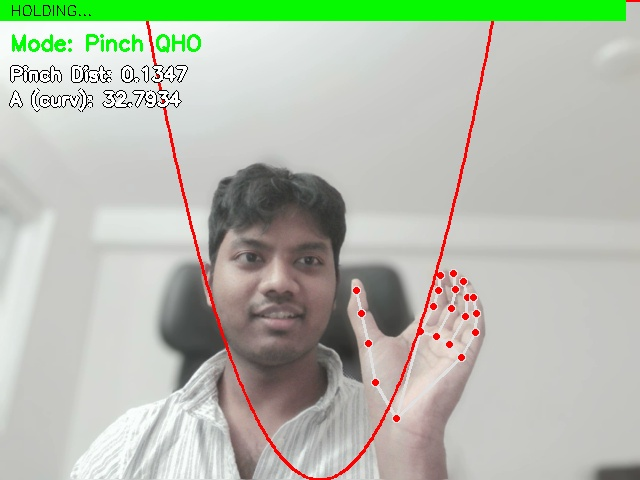

Stable capture triggered and video stream closed.


In [32]:

from functions import capture_potential_notebook
# 4. Execute Capture
print("Starting camera stream...")
# Assuming A_MIN and A_MAX are defined or hardcoded.
A_MIN = 0
A_MAX = 100 
V_raw_input = capture_potential_notebook(mode='',tune=1, A_MIN=A_MIN, A_MAX=A_MAX) 

def verify():
    if V_raw_input is not None:
        # Use the imported plot_V from your file or define it here
        # plot_V(V_raw_input) 
        print("Potential capture successful.")
    else:
        print("Potential capture failed or was aborted.")


    if V_raw_input is None:
        print("Error: Run the Camera Input cell first to get V_raw_input!")
    else:
        # --- 1. Map Input to Physics Grid (Interpolation & Scaling) ---
        
        # 1.1 Define the internal grid points for the solver
        x_solver = x[1:-1] # Interior points for V_final (length N)
        
        # 1.2 Interpolation: Map the camera's resolution to the solver's grid
        V_interpolated = np.interp(
            x_solver, 
            np.linspace(-L/2, L/2, len(V_raw_input)), # Input X-space
            V_raw_input                               # Input V-values
        )

        # 1.3 Scaling: Convert dimensionless input to energy units
        V_max_height = 100.0 # Heuristic scaling factor
        V_internal = V_interpolated * V_max_height
        
        # 1.4 Prepare V_full (The potential array including the walls, length N+2)
        # The V_full is required by your current 'solve' function signature 
        # to maintain consistency with the inf_sqaure_well definition.
        # We pad the V_internal array with 0s for the walls, knowing that 
        # the Hamiltonian construction will use V_internal (V_full[1:-1]) only.
        V_full = np.pad(V_internal, (1, 1), 'constant', constant_values=0.0)


        # --- 2. Solve H psi = E psi using defined function ---
        # The 'solve' function handles the Hamiltonian construction (T + diag(V)) 
        # and normalization internally.
        try:
            E_vals, psi_vecs = solve(T, V_full, dx)
            print(f"Solver complete. Found {E_vals.size} eigenstates.")
        
        except Exception as e:
            print(f"Error during solve: {e}")
            # Check if the potential is too high, causing numerical instability
            if np.max(V_internal) > 1e9:
                print("Potential may be too steep or high, leading to numerical error.")
            exit()


        # --- 3. Visualization using defined function (or adapted visualization) ---
        
        # The original 'plot_dead' function uses default constants (nos=5).
        # We call it here, passing the calculated results:
        
        # Note: We pass V_full to plot_dead, as it contains the boundary info
        # that your V_clipped logic uses for plotting the potential shape.
        

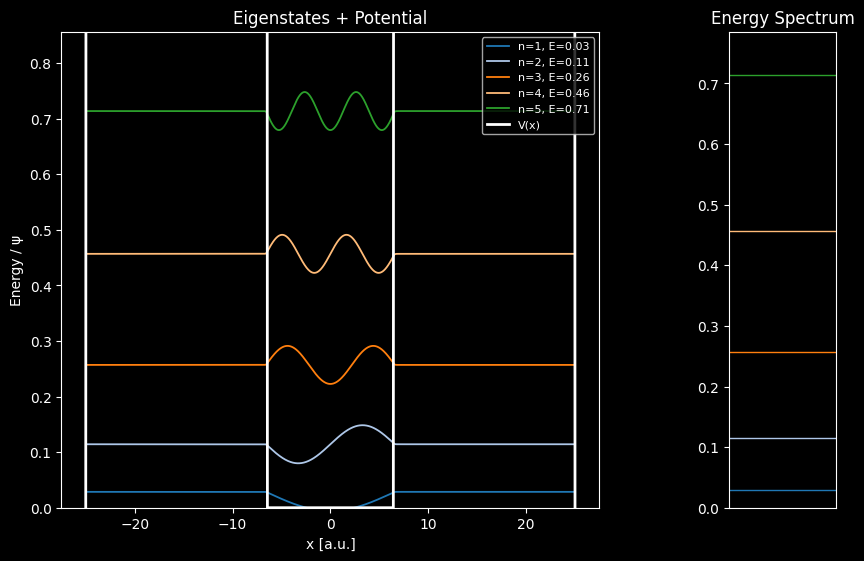

In [33]:
plot_dead(E=E_vals, psi=psi_vecs, V=V_full, x=x, nos=5);


Deploy:


https://huggingface.co/spaces/AhiBucket/Hand-wave

